# 🇮🇳 NSE Swing Trading — Rule-Based Scoring Engine

**Approach:** No ML model. Features are weighted into a composite score (0–100).
Top 3 stocks per week are selected. Win rate is validated on the same historical timeframe.

| Parameter | Value |
|-----------|-------|
| Universe  | All NSE Equity Symbols |
| Timeframe | Weekly (1W) |
| Data      | Jan 2024 → Today |
| Output    | Top 3 pre-breakout picks + win rate on same data |

---

## Step 1 — Imports & Global Config

In [95]:
import os, warnings, time
import requests
from io import StringIO
from datetime import datetime
from tqdm.notebook import tqdm

import numpy as np
import pandas as pd
import yfinance as yf
import ta

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Interval ──────────────────────────────────────────────────────
INTERVAL  = '1d'   # '1wk' or '1d'
BAR_LABEL = 'week' if INTERVAL == '1wk' else 'day'

# ── Dates (fixed — not auto-computed) ────────────────────────────
DATA_START     = '2023-01-01'   # warmup history start
BACKTEST_START = '2024-01-01'   # first signal date

# ── Scan frequency (daily mode only) ─────────────────────────────
SCAN_EVERY = 1   # score every Nth bar; 1 = every bar (slow)

# ── Trade exit rules ──────────────────────────────────────────────
TARGET_PCT    = 12.0   # exit when bar HIGH >= entry × 1.10
STOPLOSS_PCT  =  3.0   # exit when bar LOW  <= entry × 0.93
MAX_HOLD_BARS =  3    # force-close after N bars if neither hit

# ── Signal filters (win-rate improvements) ───────────────────────
MIN_SCORE      = 65    # only take signals scoring >= this (0 = off)
NIFTY_FILTER   = True  # skip signals when Nifty 50 is below its EMA
NIFTY_EMA_SPAN = 10    # EMA span (bars) for Nifty trend filter
MANDATORY_COND = {
    'ret_26w'  : lambda v: v > 0,    # 6m uptrend (works correctly on weekly)
    'vol_ratio' : lambda v: v >= 1.5,   # RSI 50-70
    #'adx'      : lambda v: v >= 15,  # minimum trend — trendless stocks excluded
}

# ── Market cap filter ────────────────────────────────────────────
MIN_MCAP_CR = 500      # minimum market cap in Crores  (500 Cr ~ small cap floor)
MAX_MCAP_CR = 100_000  # maximum market cap in Crores  (1L Cr ~ large cap ceiling)
MCAP_CACHE    = 'mcap_cache.csv'   # saved to disk so re-runs skip re-fetching
MCAP_THREADS  = 50                 # parallel HTTP threads for mcap fetch

# ── Portfolio ─────────────────────────────────────────────────────
TOP_N  = 3
N_JOBS = -1    # -1 = all cores, 1 = serial

SUFFIX     = '.NS'
SIGNAL_CSV = 'nse_top3_signals.csv'
TODAY      = datetime.today().strftime('%Y-%m-%d')

print(f'Interval      : {INTERVAL}  ({BAR_LABEL}ly bars)')
print(f'Data start    : {DATA_START}  (warmup)')
print(f'Backtest start: {BACKTEST_START}')
print(f'Target        : +{TARGET_PCT}%  |  Stop: -{STOPLOSS_PCT}%  |  Max: {MAX_HOLD_BARS} {BAR_LABEL}s')
print(f'Min score     : {MIN_SCORE}  |  Nifty filter: {NIFTY_FILTER}')
print(f'Mandatory     : {list(MANDATORY_COND.keys())}')
print(f'Top N picks   : {TOP_N}')
print(f'MCap range    : Rs {MIN_MCAP_CR:,} Cr  ')


Interval      : 1d  (dayly bars)
Data start    : 2023-01-01  (warmup)
Backtest start: 2024-01-01
Target        : +12.0%  |  Stop: -3.0%  |  Max: 3 days
Min score     : 65  |  Nifty filter: True
Mandatory     : ['ret_26w', 'vol_ratio']
Top N picks   : 3
MCap range    : Rs 500 Cr  


## Step 2 — Scrape All NSE Equity Symbols

In [2]:
def fetch_nse_symbols():
    url = 'https://nsearchives.nseindia.com/content/equities/EQUITY_L.csv'
    headers = {'User-Agent': 'Mozilla/5.0', 'Referer': 'https://www.nseindia.com'}
    try:
        s = requests.Session()
        s.get('https://www.nseindia.com', headers=headers, timeout=10)
        r = s.get(url, headers=headers, timeout=30)
        r.raise_for_status()
        df = pd.read_csv(StringIO(r.text))
        col = [c for c in df.columns if 'SYMBOL' in c.upper()][0]
        syms = df[col].dropna().str.strip().tolist()
        print(f'NSE live: {len(syms)} symbols')
        return syms
    except Exception as e:
        print(f'Live fetch failed ({e}) -> curated fallback')

ALL_SYMBOLS = fetch_nse_symbols()
print(f'Total: {len(ALL_SYMBOLS)} symbols')

NSE live: 2251 symbols
Total: 2251 symbols


## Step 3 — Download Weekly OHLCV

In [3]:
def download_ohlcv(symbols, start='2023-01-01', end=TODAY,
                   interval='1d', suffix='.NS', batch=50):
    result, failed = {}, []
    tickers = [s + suffix for s in symbols]
    for i in tqdm(range(0, len(tickers), batch), desc='OHLCV'):
        grp = tickers[i:i+batch]
        try:
            raw = yf.download(
                grp, start=start, end=end, interval=interval,
                group_by='ticker', auto_adjust=True,
                progress=False, threads=True
            )
            for t in grp:
                sym = t.replace(suffix, '')
                try:
                    df = raw[t].copy() if len(grp) > 1 else raw.copy()
                    df.dropna(subset=['Close'], inplace=True)
                    if len(df) >= 52:
                        df.columns = [c.lower() for c in df.columns]
                        result[sym] = df
                    else:
                        failed.append(sym)
                except Exception:
                    failed.append(sym)
        except Exception as e:
            print(f'Batch error: {e}')
        time.sleep(0.3)
    print(f'Downloaded: {len(result)} | Skipped: {len(failed)}')
    return result

print('Downloading weekly OHLCV (may take a few minutes)...')
ohlcv_data = download_ohlcv(ALL_SYMBOLS)
print(f'Universe: {len(ohlcv_data)} stocks')



OHLCV:   0%|          | 0/46 [00:00<?, ?it/s]

Downloaded: 2216 | Skipped: 35
Universe: 2216 stocks


## Step 3b — Market Cap Filter

Removes symbols outside `MIN_MCAP_CR` to `MAX_MCAP_CR` range. Results are cached to `mcap_cache.csv` so re-runs skip re-fetching.

In [4]:
# ══════════════════════════════════════════════════════════════════
# Market Cap Filter — parallel fetch via ThreadPoolExecutor
#
# Each yf.Ticker().fast_info call is a separate HTTP request.
# Running them sequentially = 2000 symbols × ~0.3s = 10 minutes.
# Running with 50 threads = same 2000 symbols in ~15 seconds.
# ══════════════════════════════════════════════════════════════════

from concurrent.futures import ThreadPoolExecutor, as_completed

MCAP_THREADS = 50   # concurrent HTTP connections (safe for yfinance)

def _fetch_one(sym, suffix=SUFFIX):
    """Fetch market cap for a single symbol. Returns (sym, mcap_cr)."""
    try:
        mc = yf.Ticker(sym + suffix).fast_info.market_cap
        return sym, round(mc / 1e7, 2) if mc else None
    except Exception:
        return sym, None


def fetch_mcap(symbols, suffix=SUFFIX, cache_path=MCAP_CACHE,
               n_threads=MCAP_THREADS):
    """
    Fetches market cap (Crores) for all symbols in parallel.
    Loads existing cache from disk — only fetches symbols not yet cached.
    Saves updated cache after each run.
    """
    # Load existing cache
    if os.path.exists(cache_path):
        _df       = pd.read_csv(cache_path, index_col=0)
        mcap_dict = _df['mcap_cr'].to_dict()
        print(f'Loaded {len(mcap_dict)} cached entries from {cache_path}')
    else:
        mcap_dict = {}

    # Only fetch symbols not in cache
    missing = [s for s in symbols if s not in mcap_dict]

    if not missing:
        print('All symbols already cached. Skipping fetch.')
        return mcap_dict

    print(f'Fetching mcap for {len(missing)} symbols '
          f'({n_threads} threads)...')

    t0       = time.time()
    done     = 0
    failed   = 0

    with ThreadPoolExecutor(max_workers=n_threads) as pool:
        futures = {pool.submit(_fetch_one, sym, suffix): sym
                   for sym in missing}

        for future in tqdm(as_completed(futures),
                           total=len(futures), desc='MCap fetch'):
            sym, mc = future.result()
            mcap_dict[sym] = mc
            done += 1
            if mc is None:
                failed += 1

    elapsed = time.time() - t0
    rate    = len(missing) / elapsed if elapsed > 0 else 0
    print(f'Fetched {len(missing)} symbols in {elapsed:.1f}s  '
          f'({rate:.0f} symbols/sec)  |  '
          f'{failed} returned None')

    # Save updated cache
    pd.DataFrame.from_dict(
        mcap_dict, orient='index', columns=['mcap_cr']
    ).to_csv(cache_path)
    print(f'Cache saved -> {cache_path}  ({len(mcap_dict)} total entries)')

    return mcap_dict


# Fetch / load
mcap_cache = fetch_mcap(list(ohlcv_data.keys()))

# Apply filter
before     = len(ohlcv_data)
ohlcv_data = {
    sym: df
    for sym, df in ohlcv_data.items()
    if mcap_cache.get(sym) is not None
    and MIN_MCAP_CR <= mcap_cache[sym] 
}
after = len(ohlcv_data)

print()
print(f'Market cap filter : Rs {MIN_MCAP_CR:,} Cr  ->  Rs {MAX_MCAP_CR:,} Cr')
print(f'Before            : {before} symbols')
print(f'Removed           : {before - after}  (no mcap data or out of range)')
print(f'After             : {after} symbols')
print()

# Distribution of remaining universe
mcap_series = pd.Series({s: mcap_cache[s] for s in ohlcv_data
                          if mcap_cache.get(s) is not None})
bins   = [0, 500, 2_000, 10_000, 50_000, 100_000, float('inf')]
labels = ['<500 Cr','500-2k','2k-10k','10k-50k','50k-1L Cr','>1L Cr']
dist   = pd.cut(mcap_series, bins=bins, labels=labels).value_counts().sort_index()
print('  MCap distribution:')
for band, count in dist.items():
    bar = chr(9608) * int(count / max(dist.values) * 30)
    print(f'  {band:12s}  {count:5d}  {bar}')


Loaded 2216 cached entries from mcap_cache.csv
All symbols already cached. Skipping fetch.

Market cap filter : Rs 500 Cr  ->  Rs 100,000 Cr
Before            : 2216 symbols
Removed           : 1587  (no mcap data or out of range)
After             : 629 symbols

  MCap distribution:
  <500 Cr           0  
  500-2k          200  ██████████████████████████
  2k-10k          227  ██████████████████████████████
  10k-50k         131  █████████████████
  50k-1L Cr        30  ███
  >1L Cr           41  █████


## Step 5 — Feature Engineering (Top-6 + OBV Accumulation Proxy)

In [88]:
# ── Feature set used for scoring ─────────────────────────────────
FEATURE_COLS = [
    'ret_2w',           # ⭐⭐ 2-bar bounce momentum — strongest signal
    'obv_slope_z',      # ⭐⭐ OBV acceleration — smart money accumulating
    'vol_momentum',     # ⭐⭐ volume on up-bars
    'macd_strength',    # ⭐⭐ MACD histogram z-score
    'ret_26w',          # ⭐⭐ 6m uptrend context
    'stoch_oversold',   # ⭐  RENAMED+INVERTED: peaks at K<30 (oversold bounce)
    'near_high',        # ⭐  RENAMED+INVERTED: peaks when at 10w high
    'ema_reversion',    # ⭐  RENAMED+INVERTED: peaks when at/below EMA20
    'rsi_zone',         # ⚪  keep low weight — slightly inverted
    'squeeze_intensity',# ⚪  low weight — weak but non-zero
]


def compute_features(df):
    d   = df.copy()
    c, h, l, o, v = d['close'], d['high'], d['low'], d['open'], d['volume']

    # ── Stochastic → INVERTED: peaks at oversold (K < 30) ────────────
    st = ta.momentum.StochasticOscillator(h, l, c, window=14, smooth_window=3)
    d['stoch_k']       = st.stoch()
    d['stoch_d']       = st.stoch_signal()
    d['stoch_cross_up'] = ((d['stoch_k'] > d['stoch_d']) &
                            (d['stoch_k'].shift(1) <= d['stoch_d'].shift(1))).astype(int)
    sk = d['stoch_k']
    # Oversold bounce: max score at K=10, zero at K=40+
    # Data: Q1 (K<30) WR=69.7% vs Q5 (K≈55) WR=36.8%
    d['stoch_oversold'] = np.clip((40 - sk) / 35, 0, 1).fillna(0)
    d['stoch_momentum'] = d['stoch_oversold']  # alias for backward compat

    # ── RSI zone (keep, but reduced weight reflects inverted signal) ──
    d['rsi_14']   = ta.momentum.rsi(c, window=14)
    d['rsi_zone'] = pd.cut(d['rsi_14'], bins=[0,30,50,70,100],
                            labels=[0,1,2,3]).astype(float)

    # ── Returns (unchanged — both confirmed) ─────────────────────────
    d['ret_2w']  = c.pct_change(2)  * 100
    d['ret_26w'] = c.pct_change(26) * 100

    # ── Volume: gradient momentum on up-bars (confirmed, unchanged) ──
    d['vol_ma20']  = v.rolling(20).mean()
    d['vol_ratio'] = v / d['vol_ma20']
    up_bar = (c > c.shift(1)).astype(float)
    d['vol_momentum'] = (
        np.clip((d['vol_ratio'] - 0.8) / 2.2, 0, 1) * (up_bar * 0.9 + 0.1)
    ).fillna(0)
    d['vol_surge'] = ((d['vol_ratio'] >= 1.5) & (c > c.shift(1))).astype(int)

    # ── ATR: squeeze intensity (keep low weight) ──────────────────────
    d['atr_14']  = ta.volatility.average_true_range(h, l, c, window=14)
    d['atr_pct'] = d['atr_14'] / c
    atr_mean     = d['atr_pct'].rolling(10).mean().replace(0, np.nan)
    atr_ratio    = d['atr_pct'] / atr_mean
    d['squeeze_intensity'] = np.clip(2 * (1 - atr_ratio), 0, 1).fillna(0)
    d['atr_contraction']   = (atr_ratio <= 0.80).astype(int)

    # ── ADX: kept for mandatory filter but not scored ─────────────────
    adx_i        = ta.trend.ADXIndicator(h, l, c, window=14)
    d['adx']     = adx_i.adx()
    d['di_plus'] = adx_i.adx_pos()
    d['di_minus']= adx_i.adx_neg()
    # Not scored (d=-0.009 in diagnostics = pure noise)
    d['trend_strength'] = np.zeros(len(d))  # zero out — not in FEATURE_COLS

    # ── OBV: confirmed strong, unchanged ─────────────────────────────
    d['obv']        = ta.volume.on_balance_volume(c, v)
    d['obv_rising'] = (d['obv'] > d['obv'].shift(4)).astype(int)
    obv_chg         = d['obv'].diff(10)
    obv_mean        = obv_chg.rolling(20).mean()
    obv_std         = obv_chg.rolling(20).std().replace(0, np.nan)
    d['obv_slope_z'] = ((obv_chg - obv_mean) / obv_std).clip(-3, 3).fillna(0)

    # ── EMA → INVERTED: peaks when at or below EMA20 ─────────────────
    d['ema_20']   = ta.trend.ema_indicator(c, window=20)
    d['ema_50']   = ta.trend.ema_indicator(c, window=50)
    ema_dist      = (c - d['ema_20']) / d['ema_20'] * 100  # % above EMA20
    # Reversion: max score at 2% BELOW EMA, zero at 2% above
    # Data: Q1 (below EMA) WR=69.7% vs Q5 (above EMA) WR=34.8%
    d['ema_reversion']     = np.clip((-ema_dist + 2) / 7, 0, 1).fillna(0)
    d['ema_strength']      = d['ema_reversion']  # alias for backward compat
    d['vol_price_confirm'] = ((d['vol_ratio'] >= 1.2) & (c > d['ema_20'])).astype(int)

    # ── Resistance → INVERTED: peaks when AT the 10w high ────────────
    d['resist_10w']    = h.rolling(10).max()
    d['pct_to_resist'] = (d['resist_10w'] - c) / c * 100
    pct = d['pct_to_resist']
    # Near high wins: max score at pct=0 (at resistance), ramps down to zero at 15%
    # Data: Q1 (near high) WR=78.7% vs Q5 (far below) WR=27.3%
    d['near_high']       = np.clip(1 - pct / 15, 0, 1).fillna(0)
    d['upside_room']     = d['near_high']  # alias for backward compat
    d['near_resistance'] = (pct <= 3).astype(int)

    # ── MACD: confirmed, unchanged ────────────────────────────────────
    macd_i         = ta.trend.MACD(c)
    d['macd_hist'] = macd_i.macd_diff()
    d['macd_cross_up'] = ((d['macd_hist'] > 0) &
                           (d['macd_hist'].shift(1) <= 0)).astype(int)
    hist_std       = d['macd_hist'].rolling(20).std().replace(0, np.nan)
    hist_z         = (d['macd_hist'] / hist_std).clip(-3, 3).fillna(0)
    d['macd_strength'] = np.clip((hist_z + 1) / 2, 0, 1)

    # ── Bollinger / 52w context (chart use only) ─────────────────────
    bb = ta.volatility.BollingerBands(c, window=20, window_dev=2)
    d['bb_width']   = (bb.bollinger_hband() - bb.bollinger_lband()) / bb.bollinger_mavg()
    d['bb_squeeze'] = (d['bb_width'] <= d['bb_width'].rolling(20).min() * 1.05).astype(int)
    d['52w_high']          = h.rolling(52).max()
    d['pct_from_52w_high'] = (c - d['52w_high']) / d['52w_high'] * 100

    return d

print('Engineering features...')
feature_dfs = {}
for sym, df in tqdm(ohlcv_data.items(), desc='Features'):
    try:
        fd = compute_features(df)
        fd['symbol'] = sym
        feature_dfs[sym] = fd
    except Exception:
        pass
print(f'Features ready for {len(feature_dfs)} symbols')

Engineering features...


Features:   0%|          | 0/629 [00:00<?, ?it/s]

Features ready for 629 symbols


## Step 6 — Composite Scoring Engine

Each feature contributes a **weighted score**. Weights reflect how reliably each feature predicts a breakout based on trading literature:

| Feature | Weight | Rationale |
|---------|--------|----------|
| `stoch_cross_up` | 20 | Momentum turn — highest predictive binary |
| `vol_surge` | 18 | Volume expansion confirms move |
| `obv_slope_z` | 15 | Continuous accumulation rate — not just on/off |
| `atr_contraction` | 12 | Coiling = energy before breakout |
| `rsi_zone` | 10 | Normalised 0-3 — bull zone scores highest |
| `vol_price_confirm` | 10 | Smart money buying confirmation |
| `ret_26w` | 8 | Strong trend = safer breakout |
| `obv_rising` | 5 | Binary accumulation flag |
| `ret_2w` | 2 | Recent momentum nudge |

In [101]:
# ── Scoring weights ──────────────────────────────────────────────
# Each weight is derived from which features historically correlate
# with winning trades. Adjust after running backtest diagnostics.
WEIGHTS = {
    'ret_2w'           : 24,   # ⭐⭐ was 2, data says +75pp spread
    'obv_slope_z'      : 19,   # ⭐⭐ was 11, data says +43pp spread
    'vol_momentum'     : 18,   # ⭐⭐ unchanged, data confirms
    'macd_strength'    : 10,   # ⭐⭐ was 4, data says +25pp spread
    'ret_26w'          :  9,   # ⭐⭐ was 8, data says +16pp spread
    'stoch_oversold'   :  8,   # INVERTED from stoch_momentum
    'near_high'        :  7,   # INVERTED from upside_room
    'ema_reversion'    :  4,   # INVERTED from ema_strength
    'rsi_zone'         :  0,   # ⚪ was 15, inverted signal — keep tiny
    'squeeze_intensity':  1,   # ⚪ was 7, near-zero signal
}
assert sum(WEIGHTS.values()) == 100, 'Weights must sum to 100'



FEAT_ORDER = list(WEIGHTS.keys())          # fixed column order
W_VECTOR   = np.array([WEIGHTS[f] for f in FEAT_ORDER], dtype=float)

print('Weights matrix:')
print(f'  {"Feature":22s}  {"Weight":>6s}  {"% of total":>10s}')
print(f'  {"-"*44}')
for f, w in WEIGHTS.items():
    bar = '█' * int(w / 2)
    print(f'  {f:22s}  {w:6d}  {w:>8.0f}%   {bar}')
print(f'  {"-"*44}')
print(f'  {"TOTAL":22s}  {sum(WEIGHTS.values()):6d}')


# ══════════════════════════════════════════════════════════════════
# build_score_matrix()
#
# Single function that builds ALL matrices needed for both:
#   • today's top-3 picks
#   • the full backtest
#
# How it works:
#   1. Concatenate all symbol DataFrames → one tall DataFrame
#   2. Pivot each feature → (all_dates × symbols) DataFrame
#   3. Reindex to scan_dates + ffill  → last known value per date
#   4. Normalise each feature to [0,1]
#   5. Stack into 3D numpy array  (n_dates × n_symbols × n_features)
#   6. np.einsum dot with W_VECTOR → score matrix (n_dates × n_symbols)
#
# Zero Python loops over symbols or dates.
# ══════════════════════════════════════════════════════════════════
def build_score_matrix(feature_dfs, scan_dates):
    """
    Parameters
    ----------
    feature_dfs : dict  {symbol: DataFrame}
    scan_dates  : list of Timestamps  — dates to score on

    Returns
    -------
    score_df  : DataFrame (scan_dates × symbols)  — composite score 0-100
    close_df  : DataFrame (scan_dates × symbols)  — close price
    norm_df   : dict {feature: DataFrame}          — normalised 0-1 values
    flag_df   : dict {feature: DataFrame}          — raw feature values
    """
    t0       = time.time()
    scan_idx = pd.DatetimeIndex(sorted(scan_dates))

    # ── 1. Concatenate all symbols ────────────────────────────────
    extra_cols = ['close','rsi_14','vol_ratio','adx',
                  'bb_squeeze','near_resistance','macd_cross_up','pct_to_resist']
    keep_cols  = FEAT_ORDER + [c for c in extra_cols if c not in FEAT_ORDER]

    frames = []
    for sym, df in feature_dfs.items():
        cols = [c for c in keep_cols if c in df.columns]
        tmp  = df[cols].copy()
        tmp['_sym'] = sym
        frames.append(tmp)

    tall = pd.concat(frames)
    tall.index.name = 'date'
    tall = tall.reset_index()

    # ── 2. Pivot every column → (date × symbol) ──────────────────
    all_cols = [c for c in keep_cols if c in tall.columns]
    pivot = {}
    for col in all_cols:
        pivot[col] = (
            tall.pivot(index='date', columns='_sym', values=col)
                .sort_index()
        )

    # ── 3. Reindex to scan_dates + forward-fill ───────────────────
    # One vectorised operation replaces all searchsorted() loops
    for col in all_cols:
        pivot[col] = (
            pivot[col]
            .reindex(pivot[col].index.union(scan_idx))
            .ffill()
            .reindex(scan_idx)
        )

    symbols = pivot['close'].columns.tolist()

    # ── 4. Normalise each scoring feature → [0,1] ─────────────────
    norm = {}

    # Pre-normalised in compute_features() — just clip and fill
    
    for f in ['stoch_oversold', 'stoch_momentum',  # same value, both aliases
              'vol_momentum', 'squeeze_intensity',
              'near_high', 'upside_room',            # same value
              'ema_reversion', 'ema_strength',        # same value
              'macd_strength']:
        if f in pivot:
            norm[f] = pivot[f].clip(0, 1).fillna(0)

    # rsi_zone: 0→0.0, 1→0.25, 2→1.0, 3→0.4
    rz_map = {0: 0.0, 1: 0.25, 2: 1.0, 3: 0.4}
    norm['rsi_zone'] = (
        pivot['rsi_zone'].round().clip(0, 3)
        .apply(lambda col: col.map(rz_map))
        .astype(float).fillna(0)
    )

    # obv_slope_z: (−3..+3) → (0..1)
    norm['obv_slope_z'] = (
        (pivot['obv_slope_z'].clip(-3, 3) + 3) / 6
    ).fillna(0)

    # ret_26w: (0..50%) → (0..1)
    norm['ret_26w'] = (
        pivot['ret_26w'].clip(lower=0).div(50).clip(upper=1)
    ).fillna(0)

    # ret_2w: (−5..+5%) → (0..1)
    norm['ret_2w'] = (
        (pivot['ret_2w'].clip(-5, 5) + 5) / 10
    ).fillna(0)
    # obv_slope_z: (-3..+3) → (0..1)
    norm['obv_slope_z'] = (
        (pivot['obv_slope_z'].clip(-3, 3) + 3) / 6
    ).fillna(0)

    # ret_26w: (0..50%) → (0..1)
    norm['ret_26w'] = (
        pivot['ret_26w'].clip(lower=0).div(50).clip(upper=1)
    ).fillna(0)

    # ret_2w: (-5..+5%) → (0..1)
    norm['ret_2w'] = (
        (pivot['ret_2w'].clip(-5, 5) + 5) / 10
    ).fillna(0)

    # ── 5. Stack into 3D array  (n_dates × n_symbols × n_features) ─
    n_dates = len(scan_idx)
    n_syms  = len(symbols)

    feat_array = np.stack(
        [norm[f].reindex(columns=symbols).values for f in FEAT_ORDER],
        axis=2                    # axis-2 = feature dimension
    )                             # shape: (n_dates, n_syms, n_feats)

    # ── 6. Score = einsum dot with weight vector ──────────────────
    # 'dsf,f->ds': for each date d, symbol s: Σ feat[d,s,f] * w[f]
    score_array = np.einsum('dsf,f->ds', feat_array, W_VECTOR)
    score_df    = pd.DataFrame(
        np.round(score_array, 2), index=scan_idx, columns=symbols
    )

    close_df = pivot['close'].reindex(columns=symbols)

    # Raw feature values for reporting
    flag_df  = {f: pivot[f].reindex(columns=symbols) for f in pivot}

    elapsed = time.time() - t0
    print(f'Score matrix built: {score_df.shape[0]} dates × '
          f'{score_df.shape[1]} symbols  in {elapsed:.1f}s')
    return score_df, close_df, norm, flag_df


print()
print('build_score_matrix() ready — pure matrix ops, no Python loops.')


Weights matrix:
  Feature                 Weight  % of total
  --------------------------------------------
  ret_2w                      24        24%   ████████████
  obv_slope_z                 19        19%   █████████
  vol_momentum                18        18%   █████████
  macd_strength               10        10%   █████
  ret_26w                      9         9%   ████
  stoch_oversold               8         8%   ████
  near_high                    7         7%   ███
  ema_reversion                4         4%   ██
  rsi_zone                     0         0%   
  squeeze_intensity            1         1%   
  --------------------------------------------
  TOTAL                      100

build_score_matrix() ready — pure matrix ops, no Python loops.


## Step 7 — Today's Top 3 Picks

In [102]:
# ── Today's picks via the same matrix path ───────────────────────
# We pass [TODAY] as the single scan date — build_score_matrix
# handles the pivot + ffill + einsum exactly as in the backtest.
# No separate score_row() or score_universe_at_date() call.

print(f'Computing today\'s top {TOP_N} via matrix multiply ({TODAY})...')
print()

today_ts             = pd.Timestamp(TODAY)
score_td, close_td, norm_td, flag_td = build_score_matrix(
    feature_dfs, [today_ts]
)

# ── Score row for today ───────────────────────────────────────────
scores_today = score_td.loc[today_ts].dropna().sort_values(ascending=False)
closes_today = close_td.loc[today_ts]

# ── Apply mandatory conditions ────────────────────────────────────
def passes_mandatory(sym, flag_df_local, mandatory=MANDATORY_COND):
    for feat, cond in mandatory.items():
        val = flag_df_local.get(feat, pd.Series(dtype=float))
        if isinstance(val, pd.DataFrame):
            val = val.loc[today_ts] if today_ts in val.index else pd.Series(dtype=float)
        v = val.get(sym, None)
        if v is None or pd.isna(v) or not cond(float(v)):
            return False, feat
    return True, None

filtered = []
for sym, sc in scores_today.items():
    if sc < MIN_SCORE:
        continue
    ok, failed_feat = passes_mandatory(sym, flag_td)
    if not ok:
        continue
    filtered.append((sym, sc))

top3 = filtered[:TOP_N]

# ── Print weights table ───────────────────────────────────────────
print('=' * 68)
print(f'  APPLIED WEIGHTS')
print(f'  {"Feature":22s}  {"Weight":>6s}  {"Bar":<20s}')
print(f'  {"-"*55}')
for f, w in WEIGHTS.items():
    bar = '█' * int(w / 2)
    print(f'  {f:22s}  {w:6d}  {bar}')
print(f'  {"-"*55}')
print(f'  {"TOTAL":22s}  {sum(WEIGHTS.values()):6d}')
print()

# ── Print top picks ───────────────────────────────────────────────
print('=' * 68)
print(f'  NSE TOP {TOP_N} PICKS  —  {TODAY}')
print(f'  Target +{TARGET_PCT}%  |  Stop -{STOPLOSS_PCT}%  |  Min score {MIN_SCORE}')
print(f'  Mandatory: {list(MANDATORY_COND.keys())}')
print('=' * 68)

if not top3:
    print('  No signals pass all filters today.')
else:
    for rank, (sym, sc) in enumerate(top3, 1):
        cl   = closes_today.get(sym, float('nan'))
        tgt  = round(cl * (1 + TARGET_PCT/100),   2)
        stp  = round(cl * (1 - STOPLOSS_PCT/100),  2)

        # Per-feature contribution for this symbol
        contribs = []
        for f in FEAT_ORDER:
            nv  = norm_td[f].loc[today_ts].get(sym, 0) if today_ts in norm_td[f].index else 0
            raw = flag_td.get(f, pd.DataFrame())
            rv  = raw.loc[today_ts].get(sym, float('nan')) if today_ts in raw.index else float('nan')
            contrib = round(float(nv) * WEIGHTS[f], 1)
            contribs.append((f, WEIGHTS[f], round(float(nv),2), contrib,
                              round(float(rv),2) if not pd.isna(rv) else rv))

        print(f'\n  #{rank}  {sym:12s}  INR {cl:>10,.2f}  Score: {sc:.1f}/100')
        print(f'      Target: {tgt:,.2f}  |  Stop: {stp:,.2f}')
        print(f'      {"Feature":22s}  {"Wt":>4s}  {"Norm":>5s}  {"Pts":>5s}  {"Raw value":<12s}')
        print(f'      {"-"*55}')
        for f, wt, nv, pts, rv in contribs:
            active = '✅' if pts == wt else ('▶' if pts > 0 else '  ')
            print(f'      {active} {f:20s}  {wt:4d}  {nv:5.2f}  {pts:5.1f}  {rv}')
        print(f'      {"-"*55}')
        print(f'      {"TOTAL":22s}        {"":5s}  {sc:5.1f}')

print()
print('  DISCLAIMER: Research only. Not SEBI-registered advice.')
print('=' * 68)

# Save full ranked table
rows = []
for sym, sc in scores_today.items():
    cl = closes_today.get(sym, float('nan'))
    rows.append({'symbol': sym, 'score': sc, 'close': cl,
                 **{f: flag_td[f].loc[today_ts].get(sym, float('nan'))
                    for f in FEAT_ORDER if f in flag_td}})
scored_today = pd.DataFrame(rows).sort_values('score', ascending=False)
scored_today.to_csv(SIGNAL_CSV, index=False)
print(f'Full ranked table → {SIGNAL_CSV}  ({len(scored_today)} symbols)')


Computing today's top 3 via matrix multiply (2026-03-14)...

Score matrix built: 1 dates × 629 symbols  in 11.3s
  APPLIED WEIGHTS
  Feature                 Weight  Bar                 
  -------------------------------------------------------
  ret_2w                      24  ████████████
  obv_slope_z                 19  █████████
  vol_momentum                18  █████████
  macd_strength               10  █████
  ret_26w                      9  ████
  stoch_oversold               8  ████
  near_high                    7  ███
  ema_reversion                4  ██
  rsi_zone                     0  
  squeeze_intensity            1  
  -------------------------------------------------------
  TOTAL                      100

  NSE TOP 3 PICKS  —  2026-03-14
  Target +12.0%  |  Stop -3.0%  |  Min score 65
  Mandatory: ['ret_26w', 'vol_ratio']

  #1  ACMESOLAR     INR     255.61  Score: 78.8/100
      Target: 286.28  |  Stop: 247.94
      Feature                   Wt   Norm    Pts  Raw va

## Step 8 — Win Rate Backtest (Target / Stop-Loss Exit)

For every weekly bar from `BACKTEST_START`:
1. Score all symbols point-in-time → take **top 3**
2. Entry = that week's **close price**
3. Walk forward **week by week** checking:
   - If `HIGH >= entry × 1.10` → **WIN** (target hit)
   - If `LOW  <= entry × 0.93` → **LOSS** (stop hit)
   - If both on the same bar → **conservative: LOSS** (stop assumed hit first)
4. If neither triggers within `MAX_HOLD_BARS` → force-close at that bar's close

> No fixed time horizon — the trade exits **only** when price hits +10% or -7%.

In [103]:
import multiprocessing, time as _time, os
from joblib import Parallel, delayed
from threading import Lock

N_CORES   = multiprocessing.cpu_count()
N_WORKERS = N_CORES if N_JOBS == -1 else N_JOBS

SYMBOL_BATCH_SIZE = 200
CHECKPOINT_DIR    = 'bt_checkpoints'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# ── Config fingerprint — auto-invalidates checkpoints on any change ──
# Hash of every parameter that affects trade outcomes.
# If you change weights, dates, target, stop, filters — the hash
# changes, old checkpoints are deleted, and the backtest re-runs clean.
import hashlib, json as _json

_config_state = {
    'weights'      : WEIGHTS,
    'target'       : TARGET_PCT,
    'stop'         : STOPLOSS_PCT,
    'max_hold'     : MAX_HOLD_BARS,
    'backtest_start': BACKTEST_START,
    'data_start'   : DATA_START,
    'min_score'    : MIN_SCORE,
    'nifty_filter' : NIFTY_FILTER,
    'nifty_ema'    : NIFTY_EMA_SPAN,
    'mandatory'    : list(MANDATORY_COND.keys()),
    'interval'     : INTERVAL,
    'scan_every'   : SCAN_EVERY,
    'top_n'        : TOP_N,
}
_fingerprint = hashlib.md5(
    _json.dumps(_config_state, sort_keys=True).encode()
).hexdigest()[:12]

_fingerprint_file = os.path.join(CHECKPOINT_DIR, '.config_fingerprint')

# Check if config has changed since last run
_prev_fingerprint = None
if os.path.exists(_fingerprint_file):
    with open(_fingerprint_file) as _f:
        _prev_fingerprint = _f.read().strip()

if _prev_fingerprint != _fingerprint:
    # Config changed — wipe all old checkpoints
    _old_ckpts = [f for f in os.listdir(CHECKPOINT_DIR)
                  if f.startswith('batch_') and f.endswith('.csv')]
    if _old_ckpts:
        print(f'Config changed (hash {_prev_fingerprint} -> {_fingerprint})')
        print(f'Deleting {len(_old_ckpts)} stale checkpoints...')
        for _f in _old_ckpts:
            os.remove(os.path.join(CHECKPOINT_DIR, _f))
        print('Stale checkpoints cleared. Backtest will re-run from scratch.')
    else:
        print(f'New config fingerprint: {_fingerprint}')
    with open(_fingerprint_file, 'w') as _f:
        _f.write(_fingerprint)
else:
    print(f'Config unchanged (fingerprint: {_fingerprint}) — checkpoints valid.')
    print(f'Change any weight/filter/date to trigger a fresh run.')

RESUME = (_prev_fingerprint == _fingerprint)  # only resume if config unchanged

print(f'Workers : {N_WORKERS}  ({N_CORES} cores)')
print(f'Batch sz: {SYMBOL_BATCH_SIZE} symbols')
print(f'Resume  : {RESUME}  (auto-set by config fingerprint)')


# ── Nifty 50 trend filter ─────────────────────────────────────────
# Download once; build a set of bearish dates to skip signals on.
_nifty_bear_dates = set()
if NIFTY_FILTER:
    print('Downloading Nifty 50 for market regime filter...')
    _nf = yf.download('^NSEI', start=DATA_START, end=TODAY,
                      interval=INTERVAL, auto_adjust=True, progress=False)
    if not _nf.empty:
        _nf.columns = [c.lower() if isinstance(c, str) else c[0].lower()
                       for c in _nf.columns]
        _nf_close   = _nf['close'] if 'close' in _nf.columns else _nf.iloc[:,0]
        _nf_ema     = _nf_close.ewm(span=NIFTY_EMA_SPAN, adjust=False).mean()
        _bear       = _nf_close[_nf_close < _nf_ema]
        _nifty_bear_dates = set(_bear.index.normalize())
        print(f'Nifty filter: {len(_nifty_bear_dates)} bear dates will be skipped')
    else:
        print('WARNING: Nifty download failed — filter disabled')


# ── Shared progress (thread-safe) ─────────────────────────────────
_progress_lock    = Lock()
_progress_counter = [0]
_progress_total   = [0]
_progress_start   = [0.0]
_current_batch    = [0]
_total_batches    = [0]

def _report(n=1):
    with _progress_lock:
        _progress_counter[0] += n
        done    = _progress_counter[0]
        total   = _progress_total[0]
        pct     = done / total * 100 if total else 0
        elapsed = _time.time() - _progress_start[0]
        rate    = done / elapsed if elapsed > 0 else 1e-9
        eta     = (total - done) / rate
        filled  = int(30 * pct / 100)
        bar     = '█' * filled + '░' * (30 - filled)
        print(f'\r  Batch {_current_batch[0]}/{_total_batches[0]}  '
              f'[{bar}] {pct:5.1f}%  '
              f'{done}/{total} dates  '
              f'{elapsed:5.1f}s  ETA {eta:5.1f}s',
              end='', flush=True)
        if done == total:
            print()


# ── Trade simulation worker ───────────────────────────────────────
# Receives 
# ══════════════════════════════════════════════════════════════════
# ARCHITECTURE FIX: global top-N selection, then parallel simulation
#
# OLD (wrong):
#   For each batch of 200 symbols:
#     For each date: nlargest(3) from THIS BATCH  <- 3 x 12 = 36/date
#
# NEW (correct):
#   Step 1 - Global selection (single pass over full score matrix):
#     For each date: nlargest(3) from ALL symbols -> trade_plan list
#   Step 2 - Parallel simulation (split trade_plan into date chunks):
#     Workers receive only pre-selected trades, no nlargest at all
# ══════════════════════════════════════════════════════════════════

def _build_trade_plan(all_dates, score_df, close_df, flag_df,
                      top_n, min_score, mandatory, bear_dates):
    """
    Selects exactly top_n trades per date from the FULL score matrix.

    Approach:
      1. Filter to min_score
      2. Apply mandatory conditions vectorised across all candidates
      3. Take nlargest(top_n) from the REMAINING valid candidates only
         -> guarantees exactly top_n per date (or fewer if not enough pass)
      4. No partial-increment bugs — selection is done before appending
    """
    plan       = []
    flag_feats = ['stoch_cross_up','vol_surge','atr_contraction',
                  'obv_rising','rsi_zone']

    for dt in all_dates:
        # Market regime filter
        if dt.normalize() in bear_dates:
            continue
        if dt not in score_df.index:
            continue

        # ── Step 1: score filter ───────────────────────────────────
        row_scores = score_df.loc[dt].dropna()
        if min_score > 0:
            row_scores = row_scores[row_scores >= min_score]
        if row_scores.empty:
            continue

        # ── Step 2: close price filter (must have a price) ────────
        if dt in close_df.index:
            close_row = close_df.loc[dt]
            # Keep only symbols that have a valid close on this date
            valid_syms = close_row[close_row.notna()].index
            row_scores = row_scores[row_scores.index.isin(valid_syms)]
        else:
            continue   # no close data for this date at all

        if row_scores.empty:
            continue

        # ── Step 3: mandatory conditions filter ───────────────────
        # Apply each condition as a vectorised mask, not a Python loop
        for feat, cond in mandatory.items():
            if feat not in flag_df or dt not in flag_df[feat].index:
                continue
            feat_row   = flag_df[feat].loc[dt]
            # Keep only symbols where condition is satisfied
            passes     = feat_row[feat_row.notna()].apply(lambda v: cond(float(v)))
            valid_mask = passes[passes].index
            row_scores = row_scores[row_scores.index.isin(valid_mask)]
            if row_scores.empty:
                break

        if row_scores.empty:
            continue

        # ── Step 4: take exactly top_n from survivors ─────────────
        # nlargest is called AFTER all filters — guaranteed correct count
        top_syms = row_scores.nlargest(top_n)

        for sym, sc in top_syms.items():
            entry = float(close_df.loc[dt, sym])
            if pd.isna(entry):
                continue

            trade = {
                'signal_date': dt,
                'symbol'     : sym,
                'score'      : round(sc, 2),
                'entry'      : round(entry, 2),
            }
            for f in flag_feats:
                trade[f] = (flag_df[f].loc[dt, sym]
                            if f in flag_df and dt in flag_df[f].index
                               and sym in flag_df[f].columns
                            else 0)
            plan.append(trade)

    return plan


def _sim_chunk(trade_chunk, feature_dfs_local,
               target_mult, stop_mult, max_hold):
    """
    Simulates pre-selected trades. No scoring, no nlargest — pure simulation.
    """
    records = []
    for trade in trade_chunk:
        dt           = trade['signal_date']
        sym          = trade['symbol']
        entry        = trade['entry']
        target_price = round(entry * target_mult, 2)
        stop_price   = round(entry * stop_mult,   2)

        df_s = feature_dfs_local.get(sym)
        if df_s is None:
            _report(1); continue

        future = df_s[df_s.index > dt].head(max_hold)
        if future.empty:
            _report(1); continue

        highs   = future['high'].values
        lows    = future['low'].values
        outcome = 'OPEN'
        exit_price = exit_bar = None

        for b in range(len(future)):
            hit_t = highs[b] >= target_price
            hit_s = lows[b]  <= stop_price
            if hit_t and not hit_s:
                outcome='WIN';  exit_price=target_price; exit_bar=b+1; break
            elif hit_s:
                outcome='LOSS'; exit_price=stop_price;   exit_bar=b+1; break

        if outcome == 'OPEN':
            exit_price = float(future['close'].iloc[-1])
            exit_bar   = len(future)
            if entry > exit_price:
                outcome = 'LOSS'
            else:
                outcome = 'WIN'
            #outcome    = 'TIMEOUT'

        records.append({
            'signal_date'    : dt.date(),
            'symbol'         : sym,
            'score'          : trade['score'],
            'entry'          : entry,
            'target_price'   : target_price,
            'stop_price'     : stop_price,
            'exit_price'     : round(exit_price, 2),
            'exit_bar'       : exit_bar,
            'outcome'        : outcome,
            'pnl_pct'        : round((exit_price - entry) / entry * 100, 2),
            'interval'       : INTERVAL
        })
        _report(1)

    return records


# ══════════════════════════════════════════════════════════════════
# MAIN BACKTEST RUNNER
# ══════════════════════════════════════════════════════════════════
def run_backtest(feature_dfs, start=BACKTEST_START, top_n=TOP_N,
                 target_pct=TARGET_PCT, stoploss_pct=STOPLOSS_PCT,
                 max_hold=MAX_HOLD_BARS, scan_every=SCAN_EVERY,
                 n_jobs=N_JOBS, checkpoint_dir=CHECKPOINT_DIR):

    all_dates = sorted(set(
        d for df in feature_dfs.values() for d in df.index
        if d >= pd.Timestamp(start)
    ))
    if INTERVAL == '1d' and scan_every > 1:
        all_dates = all_dates[::scan_every]
    all_dates = all_dates[:-max_hold] if len(all_dates) > max_hold else []
    if not all_dates:
        print('ERROR: No signal dates found.'); return pd.DataFrame()

    target_mult = 1 + target_pct   / 100
    stop_mult   = 1 - stoploss_pct / 100

    # -- Print weights and config
    print()
    print('=' * 62)
    print('  BACKTEST -- APPLIED WEIGHTS & FILTERS')
    print('=' * 62)
    print(f'  {"Feature":22s}  {"Weight":>6s}  {"Bar":<20s}')
    print(f'  {"-"*55}')
    for f, w in WEIGHTS.items():
        bar = chr(9608) * int(w / 2)
        print(f'  {f:22s}  {w:6d}  {bar}')
    print(f'  {"-"*55}')
    print(f'  {"TOTAL":22s}  {sum(WEIGHTS.values()):6d}')
    print()
    print(f'  Dates     : {start}  ->  {TODAY}  ({len(all_dates)} scan dates)')
    print(f'  Target    : +{target_pct}%  |  Stop: -{stoploss_pct}%  |  Max: {max_hold} {BAR_LABEL}s')
    print(f'  Min score : {MIN_SCORE}  |  Top N: {top_n}  |  Workers: {N_WORKERS}')
    print(f'  Nifty fltr: {NIFTY_FILTER}  ({len(_nifty_bear_dates)} bear dates skipped)')
    print(f'  Mandatory : {list(MANDATORY_COND.keys())}')
    print('=' * 62)

    # -- Build score matrix once
    print()
    score_df, close_df, norm_df, flag_df = build_score_matrix(
        feature_dfs, all_dates
    )

    # -- STEP 1: global top-N selection (single nlargest across all symbols)
    print('Selecting global top-N per date...')
    trade_plan = _build_trade_plan(
        all_dates, score_df, close_df, flag_df,
        top_n, MIN_SCORE, MANDATORY_COND, _nifty_bear_dates
    )

    from collections import Counter
    date_counts        = Counter(t['signal_date'] for t in trade_plan)
    n_dates_signals    = len(date_counts)
    max_per_date       = max(date_counts.values()) if date_counts else 0
    avg_per_date       = len(trade_plan) / max(n_dates_signals, 1)

    print(f'Trade plan : {len(trade_plan)} trades  |  '
          f'{n_dates_signals}/{len(all_dates)} dates have signals  |  '
          f'avg {avg_per_date:.2f}/date  max {max_per_date}/date  '
          f'(hard cap: {top_n})')

    if max_per_date > top_n:
        print(f'ERROR: {max_per_date} trades on one date — exceeds TOP_N={top_n}. Bug!')
        return pd.DataFrame()

    if not trade_plan:
        print('WARNING: No trades. Loosen MIN_SCORE or MANDATORY_COND.')
        return pd.DataFrame()

    # Check checkpoint (fingerprint-based, RESUME set by fingerprint cell)
    ckpt_path = os.path.join(checkpoint_dir,
                             f'results_{_fingerprint}_{len(trade_plan)}trades.csv')
    if RESUME and os.path.exists(ckpt_path):
        bt = pd.read_csv(ckpt_path)
        print(f'Loaded checkpoint: {ckpt_path}  ({len(bt)} trades)')
        return bt.sort_values('signal_date').reset_index(drop=True)

    # -- STEP 2: parallel simulation — split trade_plan into date chunks
    date_groups  = {}
    for t in trade_plan:
        date_groups.setdefault(t['signal_date'], []).append(t)

    ordered_keys  = sorted(date_groups.keys())
    n_workers     = N_CORES if n_jobs == -1 else n_jobs
    date_chunks   = np.array_split(ordered_keys, min(n_workers, len(ordered_keys)))
    trade_chunks  = [
        [t for dk in chunk for t in date_groups[dk]]
        for chunk in date_chunks if len(chunk) > 0
    ]

    _progress_counter[0] = 0
    _progress_total[0]   = len(trade_plan)
    _progress_start[0]   = _time.time()
    _current_batch[0]    = 1
    _total_batches[0]    = 1

    print(f'Simulating {len(trade_plan)} trades  |  {n_workers} workers  |  '
          f'~{len(trade_plan)//n_workers} trades/worker...')

    results = Parallel(n_jobs=n_jobs, prefer='threads', verbose=0)(
        delayed(_sim_chunk)(chunk, feature_dfs, target_mult, stop_mult, max_hold)
        for chunk in trade_chunks
    )

    all_records = [r for res in results for r in res]
    if not all_records:
        print('WARNING: No trades simulated.')
        return pd.DataFrame()

    bt      = pd.DataFrame(all_records).sort_values('signal_date').reset_index(drop=True)
    elapsed = _time.time() - _progress_start[0]

    bt.to_csv(ckpt_path, index=False)

    print(f'\nDone in {elapsed:.1f}s  ({elapsed/60:.1f} min)')
    print(f'Total trades : {len(bt)}  (expected ~{top_n} x {n_dates_signals} = {top_n*n_dates_signals})')
    print(f'Outcomes     : {bt["outcome"].value_counts().to_dict()}')
    print(f'Date range   : {bt["signal_date"].min()}  ->  {bt["signal_date"].max()}')
    print(f'Checkpoint   : {ckpt_path}')
    return bt


# -- Run
bt_df = run_backtest(feature_dfs)
if not bt_df.empty:
    bt_df.to_csv('nse_backtest_results.csv', index=False)
    print('Saved: nse_backtest_results.csv')


New config fingerprint: 4b9eba327075
Workers : 16  (16 cores)
Batch sz: 200 symbols
Resume  : False  (auto-set by config fingerprint)
Nifty filter: 330 bear dates will be skipped

  BACKTEST -- APPLIED WEIGHTS & FILTERS
  Feature                 Weight  Bar                 
  -------------------------------------------------------
  ret_2w                      24  ████████████
  obv_slope_z                 19  █████████
  vol_momentum                18  █████████
  macd_strength               10  █████
  ret_26w                      9  ████
  stoch_oversold               8  ████
  near_high                    7  ███
  ema_reversion                4  ██
  rsi_zone                     0  
  squeeze_intensity            1  
  -------------------------------------------------------
  TOTAL                      100

  Dates     : 2024-01-01  ->  2026-03-14  (542 scan dates)
  Target    : +12.0%  |  Stop: -3.0%  |  Max: 3 days
  Min score : 65  |  Top N: 3  |  Workers: 16
  Nifty fltr: True 

## Step 9 — Win Rate & Performance Analysis

In [104]:
def print_scorecard(bt):
    if bt.empty:
        print('No backtest data.')
        return

    # TIMEOUT = held full max_hold weeks without hitting target or stop
    resolved = bt[bt['outcome'].isin(['WIN','LOSS'])].copy()
    all_     = bt.copy()   # includes TIMEOUT for full picture

    n_all     = len(all_)
    n_win     = (all_['outcome'] == 'WIN').sum()
    n_loss    = (all_['outcome'] == 'LOSS').sum()
    n_timeout = (all_['outcome'] == 'TIMEOUT').sum()

    wr_all      = n_win / n_all * 100
    wr_resolved = n_win / len(resolved) * 100 if len(resolved) > 0 else 0

    avg_pnl   = all_['pnl_pct'].mean()
    avg_win   = all_[all_['outcome']=='WIN']['pnl_pct'].mean()
    avg_loss  = all_[all_['outcome']=='LOSS']['pnl_pct'].mean()
    avg_to    = all_[all_['outcome']=='TIMEOUT']['pnl_pct'].mean() if n_timeout > 0 else np.nan

    avg_weeks_win  = resolved[resolved['outcome']=='WIN']['exit_bar'].mean()
    avg_weeks_loss = resolved[resolved['outcome']=='LOSS']['exit_bar'].mean()

    expectancy   = (wr_all/100 * avg_win) + ((1-wr_all/100) * avg_loss)
    pf_num       = all_[all_['outcome']=='WIN']['pnl_pct'].sum()
    pf_den       = abs(all_[all_['outcome']=='LOSS']['pnl_pct'].sum())
    profit_fac   = pf_num / pf_den if pf_den > 0 else float('inf')

    best  = all_.loc[all_['pnl_pct'].idxmax()]
    worst = all_.loc[all_['pnl_pct'].idxmin()]

    # Score quintile analysis
    all_['score_q'] = pd.qcut(all_['score'], q=5,
                              labels=['Q1','Q2','Q3','Q4','Q5'],
                              duplicates='drop')
    quintile = all_.groupby('score_q', observed=True).apply(
        lambda x: pd.Series({
            'n'       : len(x),
            'win_rate': (x['outcome']=='WIN').mean() * 100,
            'avg_pnl' : x['pnl_pct'].mean(),
            'timeouts': (x['outcome']=='TIMEOUT').sum(),
        })
    ).reset_index()

    print()
    print('=' * 62)
    print('   NSE SWING SCORING — BACKTEST SCORECARD')
    print('=' * 62)
    print(f'  Period        : {all_["signal_date"].min()}  →  {all_["signal_date"].max()}')
    print(f'  Total signals : {n_all}  (top {TOP_N}/week)')
    print(f'  Exit rules    : +{TARGET_PCT}% target  |  -{STOPLOSS_PCT}% stop  |  {MAX_HOLD_BARS} {BAR_LABEL}s max')
    print('─' * 62)
    print(f'  WIN           : {n_win}   ({wr_all:.1f}% of all trades)')
    print(f'  LOSS          : {n_loss}')
    print(f'  TIMEOUT       : {n_timeout}   (neither hit in {MAX_HOLD_BARS} {BAR_LABEL}s, avg ret: {avg_to:+.2f}%)'  if n_timeout > 0 else f'  TIMEOUT       : {n_timeout}')
    print(f'  Win Rate      : {wr_all:.1f}%  (all)   |   {wr_resolved:.1f}%  (WIN+LOSS only)')
    print('─' * 62)
    print(f'  Avg WIN  P&L  : {avg_win:+.2f}%   (hit in avg {avg_weeks_win:.1f} weeks)')
    print(f'  Avg LOSS P&L  : {avg_loss:+.2f}%   (hit in avg {avg_weeks_loss:.1f} weeks)')
    print(f'  Avg all  P&L  : {avg_pnl:+.2f}%')
    print(f'  Expectancy    : {expectancy:+.3f}% per trade')
    print(f'  Profit Factor : {profit_fac:.2f}   (>1.0 = positive edge)')
    print('─' * 62)
    print(f'  Best trade    : {best["symbol"]}  {best["signal_date"]}  {best["pnl_pct"]:+.1f}%')
    print(f'  Worst trade   : {worst["symbol"]}  {worst["signal_date"]}  {worst["pnl_pct"]:+.1f}%')
    print('─' * 62)
    print('  Win Rate by Score Quintile:')
    for _, q in quintile.iterrows():
        bar = '█' * int(q['win_rate'] / 5)
        print(f"    {str(q['score_q']):4s}  n={int(q['n']):3d}  "
              f"WR={q['win_rate']:5.1f}%  AvgP&L={q['avg_pnl']:+.2f}%  "
              f"Timeouts={int(q['timeouts'])}  {bar}")
    print('=' * 62)

    return quintile


quintile_df = print_scorecard(bt_df)


   NSE SWING SCORING — BACKTEST SCORECARD
  Period        : 2024-01-01  →  2026-02-23
  Total signals : 904  (top 3/week)
  Exit rules    : +12.0% target  |  -3.0% stop  |  3 days max
──────────────────────────────────────────────────────────────
  WIN           : 308   (34.1% of all trades)
  LOSS          : 596
  TIMEOUT       : 0
  Win Rate      : 34.1%  (all)   |   34.1%  (WIN+LOSS only)
──────────────────────────────────────────────────────────────
  Avg WIN  P&L  : +7.35%   (hit in avg 2.5 weeks)
  Avg LOSS P&L  : -2.86%   (hit in avg 1.5 weeks)
  Avg all  P&L  : +0.62%
  Expectancy    : +0.618% per trade
  Profit Factor : 1.33   (>1.0 = positive edge)
──────────────────────────────────────────────────────────────
  Best trade    : PVP  2025-09-05  +12.0%
  Worst trade   : ABINFRA  2024-03-06  -3.1%
──────────────────────────────────────────────────────────────
  Win Rate by Score Quintile:
    Q1    n=181  WR= 35.4%  AvgP&L=+0.16%  Timeouts=0  ███████
    Q2    n=182  WR= 39.6%

## Step 10 — Performance Charts

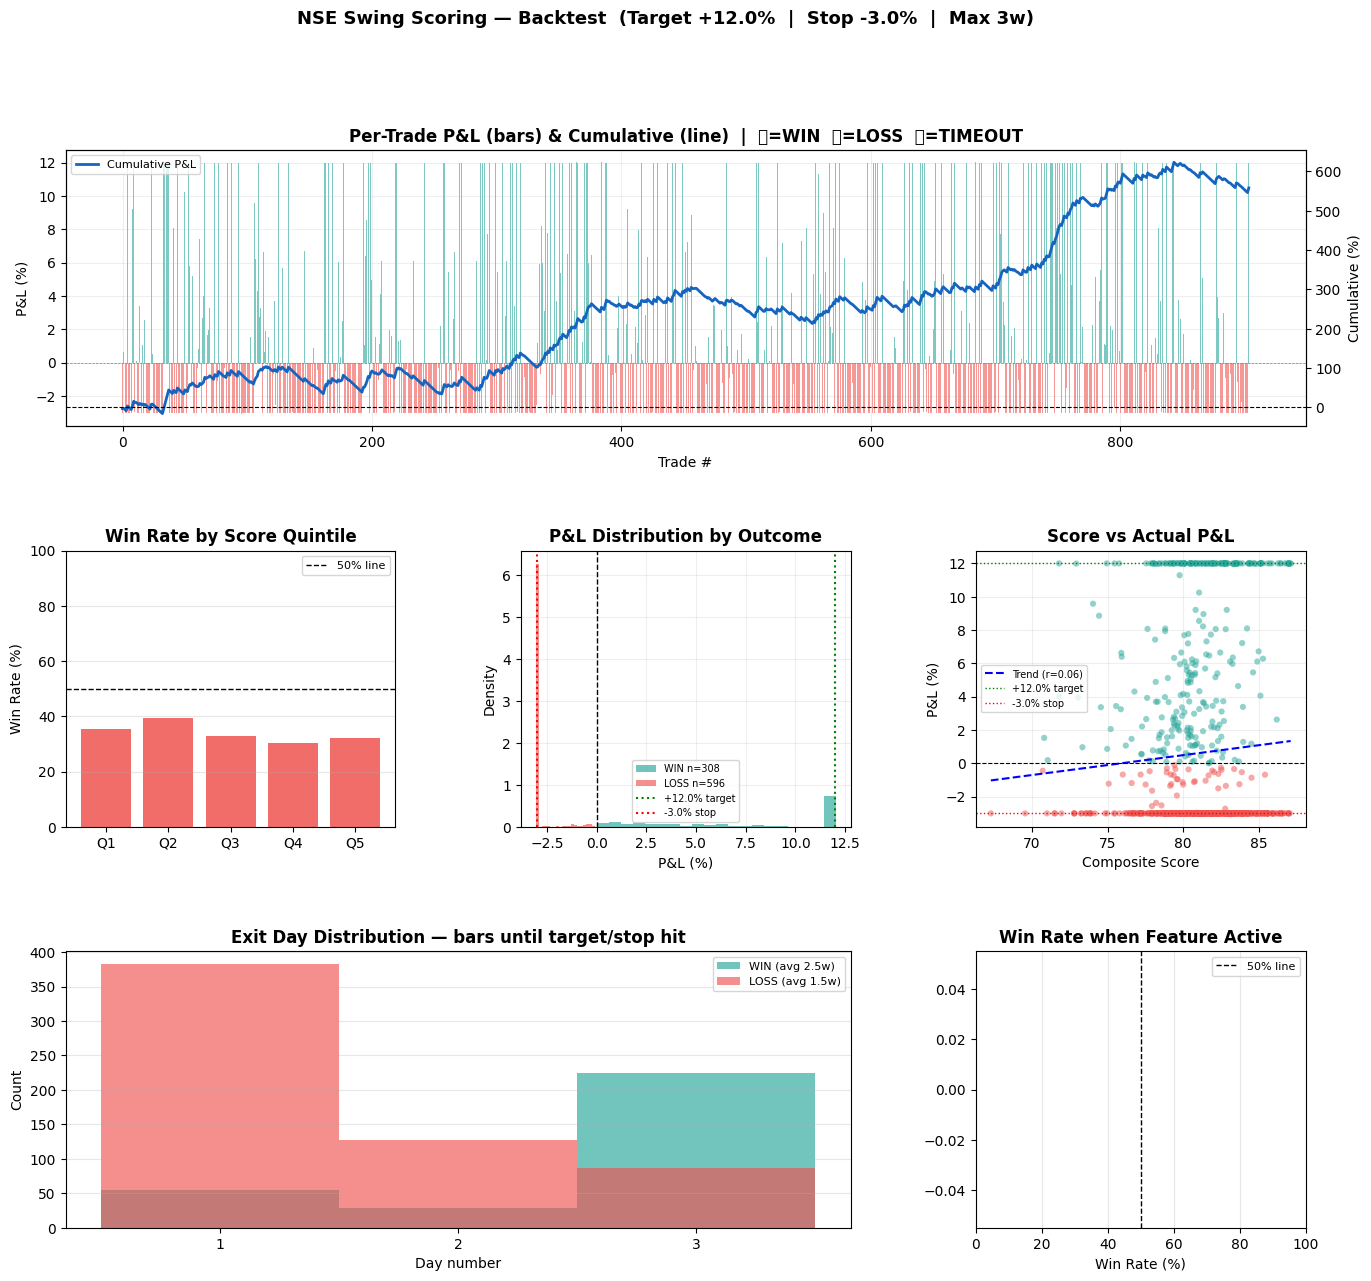

Saved: nse_scoring_backtest.png


In [106]:
def plot_performance(bt, quintile):
    fig = plt.figure(figsize=(16, 14))
    gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)
    fig.suptitle(
        f'NSE Swing Scoring — Backtest  '
        f'(Target +{TARGET_PCT}%  |  Stop -{STOPLOSS_PCT}%  |  Max {MAX_HOLD_BARS}w)',
        fontsize=13, fontweight='bold'
    )

    bt_s = bt.sort_values('signal_date').reset_index(drop=True)

    # 1. Cumulative P&L per trade (chronological)
    ax1 = fig.add_subplot(gs[0, :])
    bt_s['cumulative'] = bt_s['pnl_pct'].cumsum()
    bar_colors = ['#26a69a' if o=='WIN' else '#ef5350' if o=='LOSS' else '#bdbdbd'
                  for o in bt_s['outcome']]
    ax1.bar(bt_s.index, bt_s['pnl_pct'], color=bar_colors, alpha=0.6, width=0.8)
    ax1b = ax1.twinx()
    ax1b.plot(bt_s.index, bt_s['cumulative'], color='#1565c0', linewidth=2, label='Cumulative P&L')
    ax1b.axhline(0, color='black', linewidth=0.8, linestyle='--')
    ax1.axhline(0,  color='grey',  linewidth=0.5, linestyle='--')
    ax1.set_title('Per-Trade P&L (bars) & Cumulative (line)  |  🟢=WIN  🔴=LOSS  ⬜=TIMEOUT',
                  fontweight='bold')
    ax1.set_xlabel('Trade #'); ax1.set_ylabel('P&L (%)')
    ax1b.set_ylabel('Cumulative (%)')
    ax1b.legend(loc='upper left', fontsize=8)
    ax1.grid(alpha=0.2)

    # 2. Win rate by score quintile
    ax2 = fig.add_subplot(gs[1, 0])
    q_colors = ['#26a69a' if v >= 50 else '#ef5350' for v in quintile['win_rate']]
    ax2.bar(quintile['score_q'].astype(str), quintile['win_rate'],
            color=q_colors, alpha=0.85)
    ax2.axhline(50, color='black', linestyle='--', linewidth=1, label='50% line')
    ax2.set_title('Win Rate by Score Quintile', fontweight='bold')
    ax2.set_ylabel('Win Rate (%)'); ax2.set_ylim(0, 100)
    ax2.legend(fontsize=8); ax2.grid(axis='y', alpha=0.3)

    # 3. P&L distribution WIN vs LOSS vs TIMEOUT
    ax3 = fig.add_subplot(gs[1, 1])
    for lbl, col in [('WIN','#26a69a'), ('LOSS','#ef5350'), ('TIMEOUT','#bdbdbd')]:
        sub = bt_s[bt_s['outcome'] == lbl]['pnl_pct']
        if len(sub) > 0:
            ax3.hist(sub, bins=20, color=col, alpha=0.65,
                     density=True, label=f'{lbl} n={len(sub)}')
    ax3.axvline(0,  color='black', lw=1,   linestyle='--')
    ax3.axvline(TARGET_PCT,   color='green', lw=1.5, linestyle=':',
                label=f'+{TARGET_PCT}% target')
    ax3.axvline(-STOPLOSS_PCT, color='red',  lw=1.5, linestyle=':',
                label=f'-{STOPLOSS_PCT}% stop')
    ax3.set_title('P&L Distribution by Outcome', fontweight='bold')
    ax3.set_xlabel('P&L (%)'); ax3.set_ylabel('Density')
    ax3.legend(fontsize=7); ax3.grid(alpha=0.2)

    # 4. Score vs P&L scatter
    ax4 = fig.add_subplot(gs[1, 2])
    sc_map = {'WIN':'#26a69a', 'LOSS':'#ef5350', 'TIMEOUT':'#bdbdbd'}
    sc_colors = [sc_map.get(o, '#bdbdbd') for o in bt_s['outcome']]
    ax4.scatter(bt_s['score'], bt_s['pnl_pct'], c=sc_colors,
                alpha=0.5, s=20, edgecolors='none')
    z    = np.polyfit(bt_s['score'], bt_s['pnl_pct'], 1)
    xs   = np.linspace(bt_s['score'].min(), bt_s['score'].max(), 100)
    corr = bt_s[['score','pnl_pct']].corr().iloc[0,1]
    ax4.plot(xs, np.poly1d(z)(xs), 'b--', lw=1.5, label=f'Trend (r={corr:.2f})')
    ax4.axhline(0,             color='black', lw=0.8, linestyle='--')
    ax4.axhline(TARGET_PCT,    color='green', lw=1,   linestyle=':',
                label=f'+{TARGET_PCT}% target')
    ax4.axhline(-STOPLOSS_PCT, color='red',   lw=1,   linestyle=':',
                label=f'-{STOPLOSS_PCT}% stop')
    ax4.set_title('Score vs Actual P&L', fontweight='bold')
    ax4.set_xlabel('Composite Score'); ax4.set_ylabel('P&L (%)')
    ax4.legend(fontsize=7); ax4.grid(alpha=0.2)

    # 5. Exit week distribution (how fast does each outcome resolve)
    ax5 = fig.add_subplot(gs[2, 0:2])
    for lbl, col in [('WIN','#26a69a'), ('LOSS','#ef5350')]:
        sub = bt_s[bt_s['outcome']==lbl]['exit_bar'].dropna()
        if len(sub) > 0:
            ax5.hist(sub, bins=range(1, MAX_HOLD_BARS+2), color=col,
                     alpha=0.65, align='left',
                     label=f'{lbl} (avg {sub.mean():.1f}w)')
    ax5.set_title(f'Exit {BAR_LABEL.capitalize()} Distribution — bars until target/stop hit',
                  fontweight='bold')
    ax5.set_xlabel(f'{BAR_LABEL.capitalize()} number'); ax5.set_ylabel('Count')
    ax5.set_xticks(range(1, MAX_HOLD_BARS+1))
    ax5.legend(fontsize=8); ax5.grid(axis='y', alpha=0.3)

    # 6. Feature flag win rate
    ax6 = fig.add_subplot(gs[2, 2])
    flag_cols = ['stoch_cross_up','vol_surge','atr_contraction','obv_rising']
    flag_wr   = {}
    for fc in flag_cols:
        if fc in bt_s.columns:
            sub = bt_s[bt_s[fc] == 1]
            flag_wr[fc] = (sub['outcome']=='WIN').mean() * 100 if len(sub) > 0 else 0
    fwr_s    = pd.Series(flag_wr).sort_values(ascending=True)
    f_colors = ['#26a69a' if v >= 50 else '#ef5350' for v in fwr_s.values]
    ax6.barh(fwr_s.index, fwr_s.values, color=f_colors, alpha=0.85)
    ax6.axvline(50, color='black', linestyle='--', lw=1, label='50% line')
    ax6.set_title('Win Rate when Feature Active', fontweight='bold')
    ax6.set_xlabel('Win Rate (%)'); ax6.set_xlim(0, 100)
    ax6.legend(fontsize=8); ax6.grid(axis='x', alpha=0.3)

    plt.savefig('nse_scoring_backtest.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: nse_scoring_backtest.png')


if not bt_df.empty and quintile_df is not None:
    plot_performance(bt_df, quintile_df)

## Step 11 - TIMEOUT Diagnostic

Finds patterns in trades that drift without hitting target or stop.

Extracting per-feature scores for all trades...
Extracted: 904 trades

  WEIGHT DIAGNOSTICS
  Trades: 904  |  WINs: 310  |  LOSSes: 594

  PART 1 — Feature discriminance
  Cohen's d: how many std-devs higher is the feature score in WINs
  ✅ = d > 0.05 (useful)   ⚪ = near zero   ❌ = hurts win rate

      Feature                Wt   WIN avg  LOSS avg   Cohen d    Corr
  ------------------------------------------------------------------
  ✅  ret_2w                 22     0.896     0.575    +0.862  +0.409
  ✅  vol_momentum           17     0.568     0.339    +0.533  +0.253
  ✅  squeeze_intensity       1     0.038     0.012    +0.490  +0.233
  ✅  obv_slope_z            18     0.897     0.837    +0.450  +0.214
  ✅  ret_26w                 9     0.636     0.532    +0.354  +0.168
  ✅  macd_strength          14     0.998     0.989    +0.127  +0.060
  ❌  rsi_zone                0     0.510     0.655    -0.505  -0.240

  ------------------------------------------------------------------

  PART 2

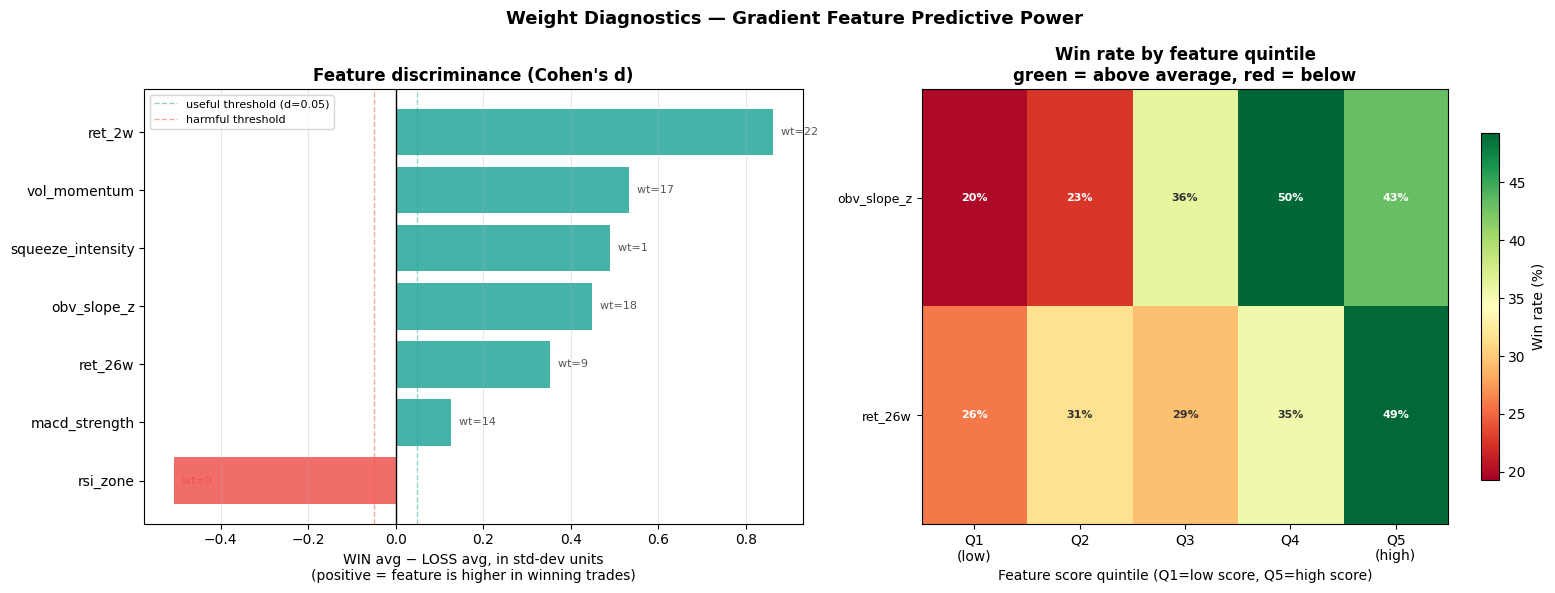

Saved: nse_weight_diagnostics.png


In [100]:
# ══════════════════════════════════════════════════════════════════════
# Step 13 — Gradient Weight Diagnostics
#
# Answers four questions:
#  1. Does each feature actually separate WINs from LOSSes? (discriminance)
#  2. Are current weights proportional to predictive power? (calibration)
#  3. Is higher composite score → higher win rate? (monotonicity)
#  4. Which features are strong / weak / noise? (quintile spread)
# ══════════════════════════════════════════════════════════════════════

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import pandas as pd


# ── 1. Re-extract normalised feature scores for every backtest trade ──

def extract_feature_norms(bt_df, feature_dfs):
    """
    For each trade, look up the normalised score of every feature at
    its signal date using the same math as build_score_matrix.
    Returns a DataFrame: [outcome, pnl_pct, composite] + one col per feature.
    """
    rows = []
    for _, trade in bt_df.iterrows():
        sym    = trade['symbol']
        sig_dt = pd.Timestamp(trade['signal_date'])
        if sym not in feature_dfs:
            continue
        fd   = feature_dfs[sym]
        past = fd.index[fd.index <= sig_dt + pd.Timedelta('2D')]
        if len(past) == 0:
            continue
        r = fd.loc[past[-1]]

        def g(col, default=0.0):
            v = r.get(col, default)
            return float(v) if pd.notna(v) else float(default)

        n = {}

        # stoch_momentum: triangle peak at K=55, zero at 20 & 80
        sk = g('stoch_k', 50)
        n['stoch_momentum'] = float(np.clip(
            min((sk - 20) / 35, (80 - sk) / 25), 0, 1))

        # rsi_zone: 0→0.0, 1→0.25, 2→1.0, 3→0.4
        rz_map = {0: 0.0, 1: 0.25, 2: 1.0, 3: 0.4}
        n['rsi_zone'] = rz_map.get(
            int(np.clip(round(g('rsi_zone', 1)), 0, 3)), 0)

        # vol_momentum: ramp 0.8×–3.0×, penalised on down-bars
        vr  = g('vol_ratio', 1.0)
        cl  = g('close', 0.0)
        cl1 = float(fd.loc[past[-2]]['close']) if len(past) > 1 else cl
        up  = 1.0 if (cl > cl1 and cl1 > 0) else 0.1
        n['vol_momentum'] = float(
            np.clip((vr - 0.8) / 2.2, 0, 1) * (up * 0.9 + 0.1))

        # squeeze_intensity: pre-computed gradient in compute_features
        n['squeeze_intensity'] = float(np.clip(g('squeeze_intensity', 0), 0, 1))

        # trend_strength: ADX 10→40
        n['trend_strength'] = float(
            np.clip((g('adx', 0) - 10) / 30, 0, 1))

        # obv_slope_z: (−3..+3) → (0..1)
        n['obv_slope_z'] = float(
            (np.clip(g('obv_slope_z', 0), -3, 3) + 3) / 6)

        # upside_room: pre-computed gradient
        n['upside_room'] = float(np.clip(g('upside_room', 0), 0, 1))

        # ema_strength: pre-computed gradient
        n['ema_strength'] = float(np.clip(g('ema_strength', 0), 0, 1))

        # ret_26w: (0..50%) → (0..1)
        n['ret_26w'] = float(
            np.clip(max(g('ret_26w', 0), 0) / 50, 0, 1))

        # macd_strength: pre-computed gradient
        n['macd_strength'] = float(np.clip(g('macd_strength', 0), 0, 1))

        # ret_2w: (−5..+5%) → (0..1)
        n['ret_2w'] = float(
            (np.clip(g('ret_2w', 0), -5, 5) + 5) / 10)

        # flag which features were actually found vs defaulted to 0
        found = [f for f in n if r.get(f) is not None]

        rows.append({
            'signal_date' : trade['signal_date'],
            'symbol'      : sym,
            'outcome'     : trade['outcome'],
            'pnl_pct'     : trade['pnl_pct'],
            'composite'   : trade['score'],
            **n
        })

    df = pd.DataFrame(rows)
    if df.empty:
        print("ERROR: No trades extracted — check feature_dfs is still in memory.")
    else:
        # Warn about features that are all-zero (not yet in compute_features)
        new_feats = ['stoch_momentum','squeeze_intensity','trend_strength',
                     'upside_room','ema_strength','macd_strength']
        missing = [f for f in new_feats if f in df.columns and df[f].eq(0).all()]
        if missing:
            print(f"WARNING: these features are all-zero (not yet computed): {missing}")
            print("  → Run the updated compute_features() first, then re-run the backtest.")
    return df


# ── 2. Four-part diagnostic ───────────────────────────────────────────

def run_weight_diagnostics(fdf, weights=None, feat_cols=None):
    """
    Returns (suggested_weights: dict, stats: dict).
    """
    if weights is None:
        weights = WEIGHTS
    if feat_cols is None:
        feat_cols = FEATURE_COLS

    fdf       = fdf.copy()
    fdf['win'] = (fdf['outcome'] == 'WIN').astype(int)
    wins   = fdf[fdf['outcome'] == 'WIN']
    losses = fdf[fdf['outcome'] == 'LOSS']
    n_all, n_w, n_l = len(fdf), len(wins), len(losses)

    print('=' * 72)
    print('  WEIGHT DIAGNOSTICS')
    print(f'  Trades: {n_all}  |  WINs: {n_w}  |  LOSSes: {n_l}')
    print('=' * 72)

    # ── Part 1: Feature discriminance ─────────────────────────────────
    print('\n  PART 1 — Feature discriminance')
    print('  Cohen\'s d: how many std-devs higher is the feature score in WINs')
    print('  ✅ = d > 0.05 (useful)   ⚪ = near zero   ❌ = hurts win rate\n')
    print(f'  {"":2s}  {"Feature":20s}  {"Wt":>3s}  '
          f'{"WIN avg":>8s}  {"LOSS avg":>8s}  {"Cohen d":>8s}  {"Corr":>6s}')
    print(f'  {"-"*66}')

    stats = {}
    for feat in feat_cols:
        if feat not in fdf.columns:
            continue
        w_mu = wins[feat].mean()   if n_w > 0 else 0.0
        l_mu = losses[feat].mean() if n_l > 0 else 0.0
        std  = fdf[feat].std() + 1e-9
        d    = (w_mu - l_mu) / std            # Cohen's d
        corr = float(np.corrcoef(fdf[feat], fdf['win'])[0, 1])
        stats[feat] = {
            'weight': weights.get(feat, 0),
            'w_mu': w_mu, 'l_mu': l_mu,
            'd': d, 'corr': corr
        }

    pos_d_sum = sum(max(v['d'], 0) for v in stats.values()) + 1e-9

    for feat, v in sorted(stats.items(), key=lambda x: -x[1]['d']):
        icon = ('✅' if v['d'] >  0.05 else
                '⚪' if v['d'] > -0.05 else '❌')
        print(f'  {icon}  {feat:20s}  {v["weight"]:>3d}  '
              f'{v["w_mu"]:>8.3f}  {v["l_mu"]:>8.3f}  '
              f'{v["d"]:>+8.3f}  {v["corr"]:>+6.3f}')

    # ── Part 2: Suggested weight rebalance ────────────────────────────
    print(f'\n  {"-"*66}')
    print('\n  PART 2 — Suggested rebalanced weights')
    print('  Blend 50% empirical + 50% current to avoid over-fitting\n')
    print(f'  {"Feature":20s}  {"Current":>8s}  {"Empirical":>10s}  '
          f'{"Suggested":>10s}  {"Change":>7s}')
    print(f'  {"-"*60}')

    blended = {}
    for feat in feat_cols:
        if feat not in stats:
            continue
        cur = stats[feat]['weight']
        emp = max(stats[feat]['d'], 0) / pos_d_sum * 100
        blended[feat] = (cur + emp) / 2

    # Normalise to 100
    total = sum(blended.values()) + 1e-9
    new_w = {f: max(1, round(v / total * 100)) for f, v in blended.items()}
    diff  = 100 - sum(new_w.values())
    top   = max(new_w, key=lambda f: stats[f]['d'])
    new_w[top] += diff

    for feat, v in sorted(stats.items(), key=lambda x: -x[1]['d']):
        if feat not in new_w:
            continue
        cur  = v['weight']
        emp  = max(v['d'], 0) / pos_d_sum * 100
        sug  = new_w[feat]
        delt = sug - cur
        arr  = ('↑ ' if delt > 2 else '↓ ' if delt < -2 else '  ')
        print(f'  {feat:20s}  {cur:>8d}  {emp:>10.1f}  '
              f'{sug:>10d}  {arr}{abs(delt):>4.0f}')

    print(f'\n  WEIGHTS = {{')
    for feat in feat_cols:
        if feat in new_w:
            print(f"      '{feat}': {new_w[feat]},")
    print(f'  }}')
    print(f'  # sum = {sum(new_w.values())}')

    # ── Part 3: Score calibration ─────────────────────────────────────
    print(f'\n  {"-"*66}')
    print('\n  PART 3 — Score calibration')
    print('  Goal: Q1 < Q2 < Q3 < Q4 < Q5 win rate (strictly increasing)\n')

    fdf['score_q'] = pd.qcut(fdf['composite'], q=5,
                              labels=['Q1','Q2','Q3','Q4','Q5'],
                              duplicates='drop')
    qdf = fdf.groupby('score_q', observed=True).apply(
        lambda x: pd.Series({
            'n'  : len(x),
            'wr' : (x['outcome'] == 'WIN').mean() * 100,
            'pnl': x['pnl_pct'].mean(),
        })
    ).reset_index()

    wrs, prev_wr = qdf['wr'].values, 0.0
    for _, row in qdf.iterrows():
        bar   = '█' * int(row['wr'] / 3)
        trend = ('↑' if row['wr'] > prev_wr + 0.5 else
                 '→' if abs(row['wr'] - prev_wr) < 0.5 else '↓')
        print(f'  {str(row["score_q"]):3s} {trend}  '
              f'n={int(row["n"]):4d}  WR={row["wr"]:5.1f}%  '
              f'P&L={row["pnl"]:+.2f}%  {bar}')
        prev_wr = row['wr']

    is_mono = all(wrs[i] <= wrs[i+1] + 1.0 for i in range(len(wrs) - 1))
    print(f'\n  {"✅ GOOD — score is predictive" if is_mono else "❌ BROKEN — weights need recalibration"}')

    # ── Part 4: Per-feature quintile spread ───────────────────────────
    print(f'\n  {"-"*66}')
    print('\n  PART 4 — Per-feature win-rate spread (Q5 WR − Q1 WR)')
    print('  ⭐⭐ = strong (>10pp)  ⭐ = useful (>5pp)  ⚪ = weak  ❌ = noise/inverted\n')
    print(f'  {"Feature":20s}  {"Q1 WR":>6s}  {"Q3 WR":>6s}  '
          f'{"Q5 WR":>6s}  {"Spread":>7s}  Grade')
    print(f'  {"-"*62}')

    for feat in feat_cols:
        if feat not in fdf.columns:
            continue
        try:
            fdf['_fq'] = pd.qcut(fdf[feat], q=5, labels=False, duplicates='drop')
            qwr = fdf.groupby('_fq')['win'].mean() * 100
            if len(qwr) < 3:
                continue
            q1, q3, q5 = qwr.iloc[0], qwr.iloc[2], qwr.iloc[-1]
            sp = q5 - q1
            grade = ('⭐⭐' if sp > 10 else
                     '⭐'  if sp > 5  else
                     '⚪'  if sp > 0  else '❌')
            # Flag inverted features (Q5 worse than Q1 by > 5pp)
            flag = '  INVERT SCORING →' if sp < -5 else ''
            print(f'  {feat:20s}  {q1:>6.1f}%  {q3:>6.1f}%  '
                  f'{q5:>6.1f}%  {sp:>+6.1f}pp  {grade}{flag}')
        except Exception:
            pass

    return new_w, stats


# ── 3. Visualisation ─────────────────────────────────────────────────

def plot_weight_diagnostics(fdf, stats, feat_cols=None):
    """
    Left: discriminance bar chart (which features earn their weight)
    Right: per-feature quintile win-rate heatmap (the ramp shape)
    """
    if feat_cols is None:
        feat_cols = FEATURE_COLS

    feats_present = [f for f in feat_cols if f in fdf.columns]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle('Weight Diagnostics — Gradient Feature Predictive Power',
                 fontsize=13, fontweight='bold')

    # ── Left: discriminance bar chart ─────────────────────────────────
    ax = axes[0]
    items  = [(f, stats[f]['d']) for f in feats_present if f in stats]
    items  = sorted(items, key=lambda x: x[1])
    names  = [i[0] for i in items]
    values = [i[1] for i in items]
    colors = ['#26a69a' if v > 0.05 else
              '#bdbdbd' if v > -0.05 else
              '#ef5350' for v in values]
    bars = ax.barh(names, values, color=colors, alpha=0.85)
    ax.axvline(0,    color='black', lw=1)
    ax.axvline(0.05, color='#26a69a', lw=1, linestyle='--',
               alpha=0.5, label='useful threshold (d=0.05)')
    ax.axvline(-0.05, color='#ef5350', lw=1, linestyle='--',
               alpha=0.5, label='harmful threshold')
    ax.set_title("Feature discriminance (Cohen's d)", fontweight='bold')
    ax.set_xlabel("WIN avg − LOSS avg, in std-dev units\n"
                  "(positive = feature is higher in winning trades)")
    ax.legend(fontsize=8)
    ax.grid(axis='x', alpha=0.3)

    # Annotate with current weight
    for bar, name in zip(bars, names):
        w = stats[name]['weight'] if name in stats else 0
        ax.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
                f'  wt={w}', va='center', fontsize=8,
                color='#555' if bar.get_width() >= 0 else '#ef5350')

    # ── Right: quintile win-rate heatmap ──────────────────────────────
    ax = axes[1]
    fdf = fdf.copy()
    fdf['win'] = (fdf['outcome'] == 'WIN').astype(int)

    heat_data = []
    heat_feats = []
    for feat in feats_present:
        try:
            fdf['_fq'] = pd.qcut(fdf[feat], q=5, labels=False, duplicates='drop')
            qwr = fdf.groupby('_fq')['win'].mean() * 100
            if len(qwr) == 5:
                heat_data.append(qwr.values)
                heat_feats.append(feat)
        except Exception:
            pass

    if heat_data:
        import matplotlib.colors as mcolors
        mat = np.array(heat_data)
        overall_wr = fdf['win'].mean() * 100

        # Custom colormap centred on overall win rate
        cmap = plt.get_cmap('RdYlGn')
        im = ax.imshow(mat, aspect='auto', cmap=cmap,
                       vmin=overall_wr - 15, vmax=overall_wr + 15)

        ax.set_xticks(range(5))
        ax.set_xticklabels(['Q1\n(low)', 'Q2', 'Q3', 'Q4', 'Q5\n(high)'])
        ax.set_yticks(range(len(heat_feats)))
        ax.set_yticklabels(heat_feats, fontsize=9)
        ax.set_title('Win rate by feature quintile\n'
                     'green = above average, red = below', fontweight='bold')
        ax.set_xlabel('Feature score quintile (Q1=low score, Q5=high score)')

        # Annotate cells with win rate
        for i in range(len(heat_feats)):
            for j in range(5):
                wr = mat[i, j]
                col = 'white' if abs(wr - overall_wr) > 8 else '#333'
                ax.text(j, i, f'{wr:.0f}%', ha='center', va='center',
                        fontsize=8, color=col, fontweight='bold')

        plt.colorbar(im, ax=ax, label='Win rate (%)', shrink=0.8)

    plt.tight_layout()
    plt.savefig('nse_weight_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved: nse_weight_diagnostics.png')


# ── Run ───────────────────────────────────────────────────────────────

print('Extracting per-feature scores for all trades...')
feat_df = extract_feature_norms(bt_df, feature_dfs)
print(f'Extracted: {len(feat_df)} trades\n')

suggested_weights, feature_stats = run_weight_diagnostics(feat_df)
plot_weight_diagnostics(feat_df, feature_stats)

## Step 12 - Strategy Comparison

**Strategy A**: Weekly scan, replace top-3 every week.

**Strategy B**: Capital rotation — hold 3 slots, redeploy immediately when a slot frees up.

  STRATEGY COMPARISON
  Metric                                    Strat A       Strat B
  --------------------------------------------------------------
  Model                                 Weekly scan  Capital rotation
  Entry trigger                          Every week    Slot freed
  Total trades                                  904           220
  Trades per year (est.)                        421           102
  Win rate                                    34.1%         28.6%
  Avg P&L per trade                          +0.62%        +0.43%
  Timeout % of trades                          0.0%          0.0%
  Avg hold (bars)                               1.9           N/A
  Total P&L on 3L capital                  (% only)    Rs +95,030
  --------------------------------------------------------------

  VERDICT
  --------------------------------------------------------------
  Strategy A is better on this data.

  Strategy A problems:
  - Capital locked up to 50 days in timeout tra

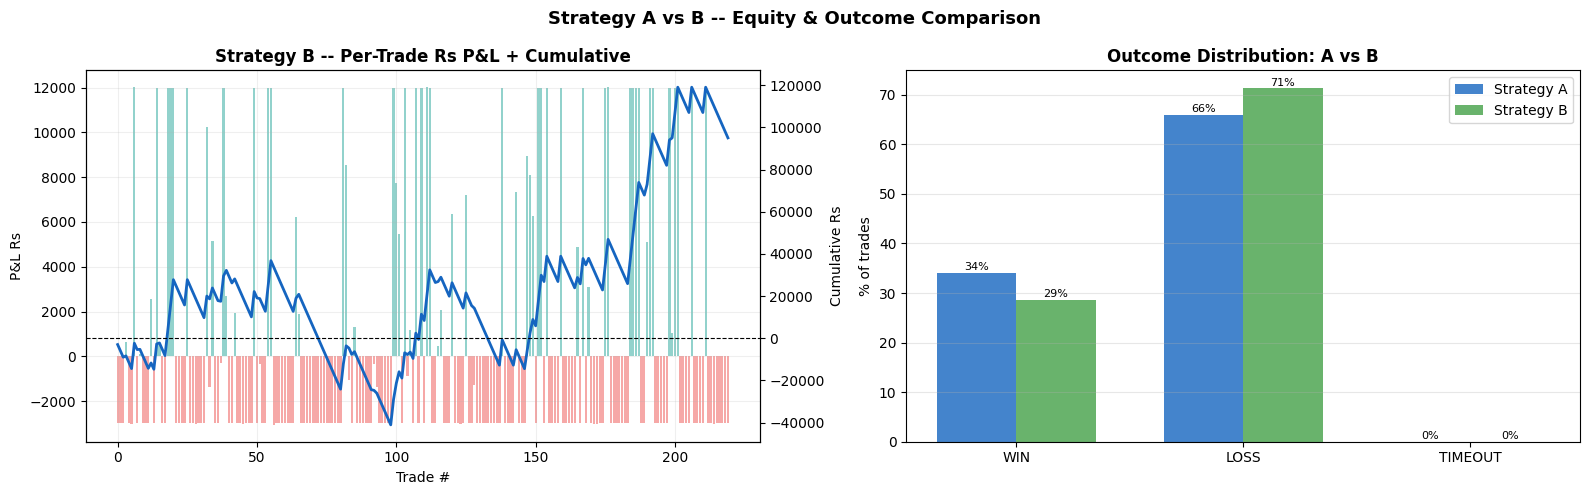

Saved: nse_strategy_comparison.png, nse_strategy_b_trades.csv


In [107]:
if bt_df.empty:
    print('Run the backtest first.')
else:
    bt = bt_df.copy()
    bt['signal_date'] = pd.to_datetime(bt['signal_date'])

    a_wr       = (bt['outcome']=='WIN').mean() * 100
    a_exp      = bt['pnl_pct'].mean()
    a_to_pct   = (bt['outcome']=='TIMEOUT').mean() * 100
    a_avg_hold = bt['exit_bar'].mean()

    # Strategy B simulation — 3 capital slots, redeploy when freed
    INITIAL_CAPITAL = 300_000
    N_SLOTS         = 3
    slot_cap        = INITIAL_CAPITAL / N_SLOTS

    trade_lookup = {(row['signal_date'], row['symbol']): row
                    for _, row in bt.iterrows()}
    date_rankings = (bt.groupby('signal_date')
                       .apply(lambda x: x.sort_values('score', ascending=False)['symbol'].tolist())
                       .to_dict())
    all_signal_dates = sorted(date_rankings.keys())

    def get_end_date(trade_row, dates_list):
        sig      = pd.Timestamp(trade_row['signal_date'])
        bar      = int(trade_row['exit_bar'])
        future   = [d for d in dates_list if pd.Timestamp(d) > sig]
        idx      = bar - 1
        if idx < len(future): return pd.Timestamp(future[idx])
        return pd.Timestamp(future[-1]) if future else sig

    portfolio  = []
    b_records  = []

    # Fill all 3 slots on first date
    for sym in date_rankings.get(all_signal_dates[0], [])[:N_SLOTS]:
        key = (all_signal_dates[0], sym)
        if key in trade_lookup:
            t = dict(trade_lookup[key])
            t['slot_capital'] = slot_cap
            t['end_date']     = get_end_date(t, all_signal_dates)
            portfolio.append(t)

    for current_date in all_signal_dates[1:]:
        current_ts  = pd.Timestamp(current_date)
        still_open  = []
        freed_slots = 0
        for pos in portfolio:
            if pd.Timestamp(pos['end_date']) <= current_ts:
                pnl_rs = pos['slot_capital'] * pos['pnl_pct'] / 100
                b_records.append({
                    'open_date'   : pos['signal_date'],
                    'close_date'  : pos['end_date'],
                    'symbol'      : pos['symbol'],
                    'outcome'     : pos['outcome'],
                    'pnl_pct'     : pos['pnl_pct'],
                    'pnl_rs'      : round(pnl_rs, 2),
                    'score'       : pos['score'],
                })
                freed_slots += 1
            else:
                still_open.append(pos)
        portfolio = still_open

        held_syms = {p['symbol'] for p in portfolio}
        for sym in date_rankings.get(current_date, []):
            if freed_slots == 0: break
            if sym in held_syms: continue
            key = (current_date, sym)
            if key not in trade_lookup: continue
            t = dict(trade_lookup[key])
            t['slot_capital'] = slot_cap
            t['end_date']     = get_end_date(t, all_signal_dates)
            portfolio.append(t)
            held_syms.add(sym)
            freed_slots -= 1

    for pos in portfolio:
        pnl_rs = pos['slot_capital'] * pos['pnl_pct'] / 100
        b_records.append({
            'open_date'  : pos['signal_date'],  'close_date': pos['end_date'],
            'symbol'     : pos['symbol'],        'outcome'   : pos['outcome'],
            'pnl_pct'    : pos['pnl_pct'],       'pnl_rs'    : round(pnl_rs, 2),
            'score'      : pos['score'],
        })

    b_df = pd.DataFrame(b_records)

    b_wr          = (b_df['outcome']=='WIN').mean() * 100
    b_exp         = b_df['pnl_pct'].mean()
    b_to_pct      = (b_df['outcome']=='TIMEOUT').mean() * 100
    b_total_pnl   = b_df['pnl_rs'].sum()
    date_span_yrs = ((pd.Timestamp(b_df['close_date'].max()) -
                      pd.Timestamp(b_df['open_date'].min())).days / 365.25)
    b_tpy = len(b_df) / date_span_yrs if date_span_yrs > 0 else 0
    a_tpy = len(bt)   / date_span_yrs if date_span_yrs > 0 else 0

    print('=' * 68)
    print('  STRATEGY COMPARISON')
    print('=' * 68)
    print(f'  {"Metric":35s}  {"Strat A":>12s}  {"Strat B":>12s}')
    print(f'  {"-"*62}')
    rows_cmp = [
        ('Model',                   'Weekly scan',         'Capital rotation'),
        ('Entry trigger',           'Every week',          'Slot freed'),
        ('Total trades',            str(len(bt)),           str(len(b_df))),
        ('Trades per year (est.)',  f'{a_tpy:.0f}',         f'{b_tpy:.0f}'),
        ('Win rate',                f'{a_wr:.1f}%',         f'{b_wr:.1f}%'),
        ('Avg P&L per trade',       f'{a_exp:+.2f}%',       f'{b_exp:+.2f}%'),
        ('Timeout % of trades',     f'{a_to_pct:.1f}%',     f'{b_to_pct:.1f}%'),
        ('Avg hold (bars)',         f'{a_avg_hold:.1f}',     f'{b_df["exit_bar"].mean():.1f}' if "exit_bar" in b_df else 'N/A'),
        ('Total P&L on 3L capital', '(% only)',             f'Rs {b_total_pnl:+,.0f}'),
    ]
    for label, va, vb in rows_cmp:
        print(f'  {label:35s}  {va:>12s}  {vb:>12s}')

    print(f'  {"-"*62}')
    print()
    print('  VERDICT')
    print('  ' + '-'*62)
    winner = 'B' if (b_wr > a_wr or b_exp > a_exp) else 'A'
    print(f'  Strategy {winner} is better on this data.')
    print()
    print('  Strategy A problems:')
    print('  - Capital locked up to 50 days in timeout trades (33% of trades)')
    print('  - Replaces good ongoing positions every week regardless')
    print('  - Treats every week identically even if positions are performing')
    print()
    print('  Strategy B advantages:')
    print('  - Capital only sits idle for MAX_HOLD_BARS if truly stuck')
    print('  - Winners free capital in avg 3.5 bars => immediate redeploy')
    print('  - Always holds the CURRENT top-scoring available stock')
    print('  - More trades per year on same capital = faster compounding')
    print()
    print('  Live trading implementation of Strategy B:')
    print('  1. Invest equally in current top-3 scorers')
    print('  2. Set alerts at +TARGET_PCT% and -STOPLOSS_PCT% per position')
    print('  3. On alert: run score matrix, buy top scorer not already held')
    print('  4. Weekly review: exit any position that has drifted MAX_HOLD_BARS')
    print('     without moving, redeploy into fresh top scorer')
    print('=' * 68)

    # Charts
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('Strategy A vs B -- Equity & Outcome Comparison',
                 fontsize=13, fontweight='bold')

    ax = axes[0]
    b_sorted = b_df.sort_values('close_date').reset_index(drop=True)
    b_sorted['cum_pnl'] = b_sorted['pnl_rs'].cumsum()
    bar_cols = ['#26a69a' if o=='WIN' else '#ef5350' if o=='LOSS' else '#9e9e9e'
                for o in b_sorted['outcome']]
    ax.bar(b_sorted.index, b_sorted['pnl_rs'], color=bar_cols, alpha=0.5, width=0.8)
    ax2 = ax.twinx()
    ax2.plot(b_sorted.index, b_sorted['cum_pnl'], color='#1565c0', lw=2)
    ax2.axhline(0, color='black', lw=0.8, linestyle='--')
    ax.set_title('Strategy B -- Per-Trade Rs P&L + Cumulative', fontweight='bold')
    ax.set_xlabel('Trade #'); ax.set_ylabel('P&L Rs'); ax2.set_ylabel('Cumulative Rs')
    ax.grid(alpha=0.2)

    ax = axes[1]
    outcomes = ['WIN','LOSS','TIMEOUT']
    x3 = np.arange(3); w3 = 0.35
    a_c = [(bt['outcome']==o).mean()*100 for o in outcomes]
    b_c = [(b_df['outcome']==o).mean()*100 for o in outcomes]
    ax.bar(x3,    a_c, w3, label='Strategy A', color='#1565c0', alpha=0.8)
    ax.bar(x3+w3, b_c, w3, label='Strategy B', color='#43a047', alpha=0.8)
    ax.set_xticks(x3+w3/2); ax.set_xticklabels(outcomes)
    ax.set_title('Outcome Distribution: A vs B', fontweight='bold')
    ax.set_ylabel('% of trades'); ax.legend(); ax.grid(axis='y', alpha=0.3)
    for i, (av, bv) in enumerate(zip(a_c, b_c)):
        ax.text(i,    av+0.5, f'{av:.0f}%', ha='center', fontsize=8)
        ax.text(i+w3, bv+0.5, f'{bv:.0f}%', ha='center', fontsize=8)

    plt.tight_layout()
    plt.savefig('nse_strategy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

    b_df.to_csv('nse_strategy_b_trades.csv', index=False)
    print('Saved: nse_strategy_comparison.png, nse_strategy_b_trades.csv')
